# Progetto di Machine Learning : 

Studente : Quadrini Mattia 

### 1) Ricerca dei migliori parametri per la rete neurale

In [1]:
pip install tensorflow

In [2]:
pip install scikeras

Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os

np.random.seed(42)                 # Impostiamo i seed randomici per numpy
tf.random.set_seed(42)             # Impostiamo i seed randomici per tensorflow

#Definiamo come mostrare i grafici 
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)       # Imposta la dimensione del testo delle etichette a 14px
mpl.rc('xtick', labelsize=12)      # Imposta la dimensione del testo delle etichette dell'asse x a 12px
mpl.rc('ytick', labelsize=12)      # Imposta la dimensione del testo delle etichette dell'asse y a 12px

In [5]:
import pandas as pd

df = pd.read_csv("emnist-letters.csv")   #Utilizzato per leggere il file .csv del nostro database
                                         #  e memorizzare i dati in un Data Frame. 
                                         #  Il DataFrame è una struttura dati tabellare che consente facilmente 
                                         #  la manipolazione dei dati tabulari.

X = df.iloc[:,1:].to_numpy().reshape(-1, 28, 28, order="F") # Convertiamo i dati delle colonne del DataFrame in un array tridimensionale
                                                            #   NumPy in cui ogni campione è un immagine 28x28pixel. 

X=X/255                                  # Conversione da dati "int64" a "float64"

y = df.iloc[:,0].to_numpy()-1            # Convertiamo i dati delle etichette e portiamolo come vettore NumPy 
                                         # in cui per ogni campione indica la label corrispondente 

print("Dimensione di X:", X.shape)       # Print della dimensione della matrice delle feature
print("Dimensione di y: ", y.shape)      # Print della dimensione della matrice delle label

Dimensione di X: (88799, 28, 28)
Dimensione di y:  (88799,)


In [6]:
from sklearn.model_selection import train_test_split

#Divido il dataset in Training Set, Validation Set e Test Set
XTraining, X_temp, YTraining, y_temp = X, y, test_size=0.2, random_state=42)
XValidation, XTest, YValidation, YTest = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Porzione di Training", XTraining.shape, YTraining.shape)
print("Porzione di Validation", XValidation.shape, YValidation.shape)
print("Porzione di Test", XTest.shape, YTest.shape)

Porzione di Training (71039, 28, 28) (71039,)
Porzione di Validation (8880, 28, 28) (8880,)
Porzione di Test (8880, 28, 28) (8880,)


In [7]:
# DEFINIAMO LA FUNZIONE BUILD MODEL 
# Questa funzione è progettata per creare una rete neurale sequenziale con un numero specificato di strati nascosti,
# numero di neuroni di ogni strato nascosto e tasso di apprendimento (learning rate).

def build_model (n_hidden=3, n_units=100, learning_rate=0.01):
    model = keras.models.Sequential()                          # Crea un modello sequenziale, dove vengono aggiunti strati uno alla volta.
    model.add(keras.layers.Flatten(input_shape=[28, 28]))      # Crea uno strati "Flatten" dove converte una immagine 28x28 in un array monodimensionale di 784 elementi. (Input Layer)
    for i in range(n_hidden):                                  # Aggiunge n_hidden strati nascosti 
        model.add(keras.layers.Dense(n_units, activation="relu"))
            
    model.add(keras.layers.Dense(26, activation="softmax"))    # Crea uno strato di output denso di 26 elementi con fuznione di attivazione softmax (Output Layer)

    model.compile(loss="sparse_categorical_crossentropy",      # Compila il modello specificando la funzione di perdita, l'ottimizzatore e le metriche da monitorare durante l'addestramento.
              optimizer=keras.optimizers.SGD(lr=learning_rate),
              metrics=["accuracy"])
    
    model.summary()   # Mostriamo il sommario della rete neurale cosi generata. 
 
    
    return model

In [8]:
from scipy.stats import reciprocal
import sklearn
from sklearn.model_selection import RandomizedSearchCV

# E' un dizionario che ti segna i range degli iperparametri. 
param_distribs = {
    "n_hidden": [0, 1, 2, 3, 4, 5],
    "n_units": np.arange(50, 200).tolist(),
    "learning_rate": reciprocal(1e-4, 1e-2).rvs(1000).tolist(),
}
# n_hidden : specifica il numero di strati nascosti del modello. 
# n_units : specifica il numero di ciascuna unità in ciascuno strato nascosto. 
# learning_rate : specifica il tasso di apprendimento. 
#                 reciprocal : indica la creazione di una distribuzione reciproca nell'intervallo selezionato
#                 rvs : genera "x" campioni casuali dalla distribuzione reciproca. 
#                 tolist : converte l'array numpy in una lista python.


from scikeras.wrappers import KerasClassifier


keras_clf = KerasClassifier(
    model=build_model,
    loss="sparse_categorical_crossentropy",
    n_units=1, n_hidden=1, learning_rate=0.001 
)
# Keras classifier è una classe che consente di utilizzare modelli Keras come stimatori.
#  Model : utilizza la funzione definita precedentemnente per creare il modello Keras da addestrare.
#  Loss : Specifica la funzione di loss applicata per addestrare il modello. 
#  n_units, n_hidden, learning_rate : fornisce valori predefiniti per alcuni degli iperparametri del modello. 


# RandomizedSearchCV è una classe utile per eseguire una ricerca casuale nell'ottimizzazione degli iperparametri di un modello Keras. 
rnd_search_cv = RandomizedSearchCV(keras_clf, param_distribs, n_iter=10, cv=5, verbose=2) # toy params

#rnd_searcj_cv.fit utilizza la fase di addestramento del modello Keras con una ricerca casuale degli iperparametri. 
rnd_search_cv.fit(XTraining, YTraining, epochs=45,
                  validation_data=(XValidation, YValidation),
                  callbacks=[keras.callbacks.EarlyStopping(patience=5)])

Fitting 5 folds for each of 10 candidates, totalling 50 fits



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 128)               16512     
                                                                 
 dense_3 (Dense)             (None, 128)               16512     
                                                                 
 dense_4 (Dense)             (None, 26)                3354      
                                                                 
Total params: 153370 (599.10 KB)
Trainable params: 15337

1776/1776 [==============================] - 8s 4ms/step - loss: 1.9510 - accuracy: 0.4483 - val_loss: 1.1992 - val_accuracy: 0.6414
Epoch 2/45
1776/1776 [==============================] - 7s 4ms/step - loss: 0.9971 - accuracy: 0.7056 - val_loss: 0.8566 - val_accuracy: 0.7475
Epoch 3/45
1776/1776 [==============================] - 6s 3ms/step - loss: 0.7614 - accuracy: 0.7732 - val_loss: 0.7139 - val_accuracy: 0.7832
Epoch 4/45
1776/1776 [==============================] - 7s 4ms/step - loss: 0.6280 - accuracy: 0.8124 - val_loss: 0.6210 - val_accuracy: 0.8143
Epoch 5/45
1776/1776 [==============================] - 9s 5ms/step - loss: 0.5417 - accuracy: 0.8351 - val_loss: 0.5612 - val_accuracy: 0.8265
Epoch 6/45
1776/1776 [==============================] - 10s 6ms/step - loss: 0.4859 - accuracy: 0.8506 - val_loss: 0.5186 - val_accuracy: 0.8452
Epoch 7/45
1776/1776 [==============================] - 11s 6ms/step - loss: 0.4440 - accuracy: 0.8635 - val_loss: 0.4693 - val_accuracy: 0.8571
E

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_5 (Dense)             (None, 128)               100480    
                                                                 
 dense_6 (Dense)             (None, 128)               16512     
                                                                 
 dense_7 (Dense)             (None, 128)               16512     
                                                                 
 dense_8 (Dense)             (None, 128)               16512     
                                                                 
 dense_9 (Dense)             (None, 26)                3354      
                                                                 
Total params: 153370 (599.10 KB)
Trainable params: 153

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_10 (Dense)            (None, 128)               100480    
                                                                 
 dense_11 (Dense)            (None, 128)               16512     
                                                                 
 dense_12 (Dense)            (None, 128)               16512     
                                                                 
 dense_13 (Dense)            (None, 128)               16512     
                                                                 
 dense_14 (Dense)            (None, 26)                3354      
                                                                 
Total params: 153370 (599.10 KB)
Trainable params: 153

...

Model: "sequential_47"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_47 (Flatten)        (None, 784)               0         
                                                                 
 dense_178 (Dense)           (None, 144)               113040    
                                                                 
 dense_179 (Dense)           (None, 144)               20880     
                                                                 
 dense_180 (Dense)           (None, 144)               20880     
                                                                 
 dense_181 (Dense)           (None, 26)                3770      
                                                                 
Total params: 158570 (619.41 KB)
Trainable params: 158570 (619.41 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/45
17

Model: "sequential_48"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_48 (Flatten)        (None, 784)               0         
                                                                 
 dense_182 (Dense)           (None, 144)               113040    
                                                                 
 dense_183 (Dense)           (None, 144)               20880     
                                                                 
 dense_184 (Dense)           (None, 144)               20880     
                                                                 
 dense_185 (Dense)           (None, 26)                3770      
                                                                 
Total params: 158570 (619.41 KB)
Trainable params: 158570 (619.41 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/45
17

Model: "sequential_49"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_49 (Flatten)        (None, 784)               0         
                                                                 
 dense_186 (Dense)           (None, 144)               113040    
                                                                 
 dense_187 (Dense)           (None, 144)               20880     
                                                                 
 dense_188 (Dense)           (None, 144)               20880     
                                                                 
 dense_189 (Dense)           (None, 26)                3770      
                                                                 
Total params: 158570 (619.41 KB)
Trainable params: 158570 (619.41 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/45
17

Model: "sequential_50"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_50 (Flatten)        (None, 784)               0         
                                                                 
 dense_190 (Dense)           (None, 170)               133450    
                                                                 
 dense_191 (Dense)           (None, 170)               29070     
                                                                 
 dense_192 (Dense)           (None, 170)               29070     
                                                                 
 dense_193 (Dense)           (None, 170)               29070     
                                                                 
 dense_194 (Dense)           (None, 26)                4446      
                                                                 
Total params: 225106 (879.32 KB)
Trainable params: 22

RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(learning_rate=0.001, loss='sparse_categorical_crossentropy', model=<function build_model at 0x000001BF5BDFD4E0>, n_hidden=1, n_units=1),
                   param_distributions={'learning_rate': [0.0005611516415334504,
                                                          0.007969454818643928,
                                                          0.002910635913133069,
                                                          0.0015751320499779724,
                                                          0.00020513382630874495,
                                                          0.00020511104188433973,
                                                          0...
                                                          0.0016738085788752125,
                                                          0.00019010245319870352,
                                                          0.00038396292998041706,
                                                          0.0005404103854647328,
                                                          0.0008168455894760164,
                                                          0.0037183641805732066,
                                                          0.00025081156860452326,
                                                          0.001067748270948135,
                                                          0.001530485212183146,
                                                          0.00012385137298860928, ...],
                                        'n_hidden': [0, 1, 2, 3, 4, 5],
                                        'n_units': [50, 51, 52, 53, 54, 55, 56,
                                                    57, 58, 59, 60, 61, 62, 63,
                                                    64, 65, 66, 67, 68, 69, 70,
                                                    71, 72, 73, 74, 75, 76, 77,
                                                    78, 79, ...]},
                   verbose=2)

In [10]:
rnd_search_cv.best_params_

{'n_units': 170, 'n_hidden': 4, 'learning_rate': 0.006559958964361444}

In [11]:
model = rnd_search_cv.best_estimator_.model_

In [12]:
model.evaluate(XTest, YTest)

278/278 [==============================] - 1s 3ms/step - loss: 0.4326 - accuracy: 0.8948


[0.43257129192352295, 0.8948197960853577]

### 2) Utilizzo rete neurale utilizzando i migliori paramentri calcolati precedentemente

In [13]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install graphviz 

Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install pydot pydotplus

In [16]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os

np.random.seed(42)                 # Impostiamo i seed randomici per numpy
tf.random.set_seed(42)             # Impostiamo i seed randomici per tensorflow

#Definiamo come mostrare i grafici 
%matplotlib inline                 
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)       # Imposta la dimensione del testo delle etichette a 14px
mpl.rc('xtick', labelsize=12)      # Imposta la dimensione del testo delle etichette dell'asse x a 12px
mpl.rc('ytick', labelsize=12)      # Imposta la dimensione del testo delle etichette dell'asse y a 12px

In [17]:
import pandas as pd

df = pd.read_csv("emnist-letters.csv")   #Utilizzato per leggere il file .csv del nostro database
                                         #  e memorizzare i dati in un Data Frame. 
                                         #  Il DataFrame è una struttura dati tabellare che consente facilmente 
                                         #  la manipolazione dei dati tabulari.

X = df.iloc[:,1:].to_numpy().reshape(-1, 28, 28, order="F") # Convertiamo i dati delle colonne del DataFrame in un array tridimensionale
                                                            #   NumPy in cui ogni campione è un immagine 28x28pixel. 

X=X/255                                  # Conversione da dati "int64" a "float64"

y = df.iloc[:,0].to_numpy()-1            # Convertiamo i dati delle etichette e portiamolo come vettore NumPy in cui ogni campioni indica la label corrispondente 

print("Dimensione di X:", X.shape)       # Print della dimensione della matrice delle feature
print("Dimensione di y: ", y.shape)      # Print della dimensione della matrice delle label

Dimensione di X: (88799, 28, 28)
Dimensione di y:  (88799,)


In [18]:
N_Campioni = X.shape[0]
from sklearn.model_selection import train_test_split
XTraining, X_temp, YTraining, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
XValidation, XTest, YValidation, YTest = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print("Porsione di Training", XTraining.shape, YTraining.shape)
print("Porsione di Validation", XValidation.shape, YValidation.shape)
print("Porsione di Test", XTest.shape, YTest.shape)

Porsione di Training (71039, 28, 28) (71039,)
Porsione di Validation (8880, 28, 28) (8880,)
Porsione di Test (8880, 28, 28) (8880,)


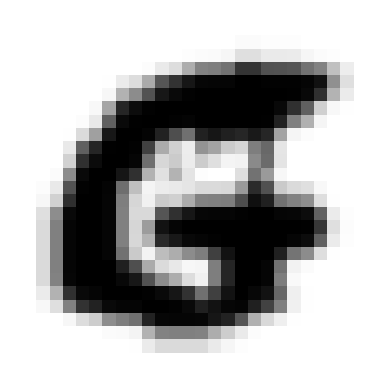

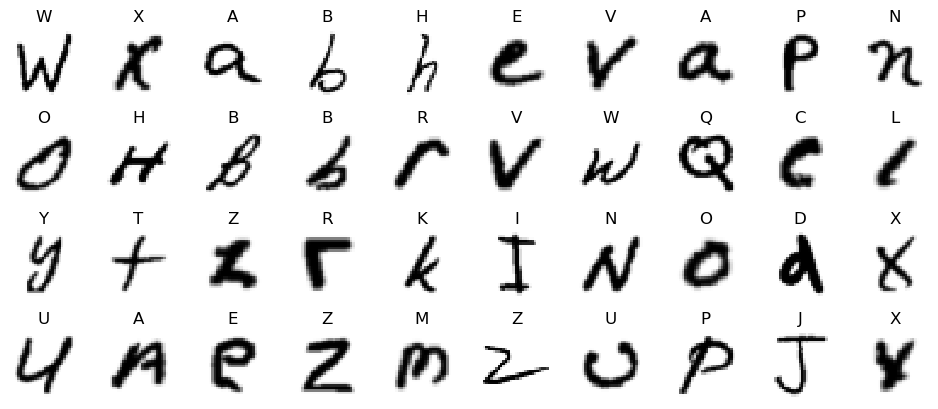

In [19]:
#test print immagini
plt.imshow(X[0], cmap="binary")
plt.axis('off')
plt.show()

# Print di alcuni campioni di immagini presenti 
n_rows = 4
n_cols = 10
class_names = ["A", "B", "C", "D", "E", "F", "G", "H", "I","J","K", "L", "M","N",
              "O","P","Q", "R", "S", "T", "U","V","W","X","Y","Z"]
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(XTraining[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[YTraining[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Model: "sequential_51"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_51 (Flatten)        (None, 784)               0         
                                                                 
 dense_195 (Dense)           (None, 170)               133450    
                                                                 
 dense_196 (Dense)           (None, 170)               29070     
                                                                 
 dense_197 (Dense)           (None, 170)               29070     
                                                                 
 dense_198 (Dense)           (None, 170)               29070     
                                                                 
 dense_199 (Dense)           (None, 26)                4446      
                                                                 
Total params: 225106 (879.32 KB)
Trainable params: 22

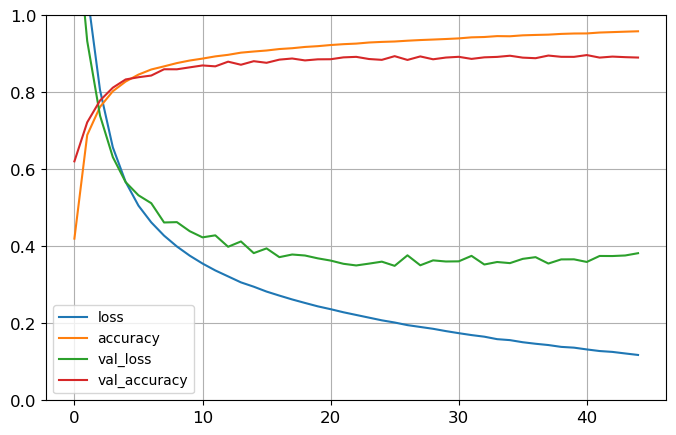

In [20]:
# CREAZIONE DELLA RETE NEURALE 
# Creiamo lo strato in input 28x28 
# Creiamo il primo strato nascosto denso di 170 neuroni con funzione di attivazione "ReLU"
# Creiamo il secondo strato nascosto denso di 170 neuroni con funzione di attivazione "ReLU"
# Creiamo il terzo strato nascosto denso di 170 neuroni con funzione di attivazione "ReLU"
# Creiamo il quarto strato nascosto denso di 170 neuroni con funzione di attivazione "ReLU"
# Creiamo lo strato in output denso con 26 neuroni (equivalente alle label) con funzione di attivazione SoftMax
#         la quale ci restituisce una certa probabilità di appartenere a una data classe. 

model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(170, activation="relu"))
model.add(keras.layers.Dense(170, activation="relu"))
model.add(keras.layers.Dense(170, activation="relu"))
model.add(keras.layers.Dense(170, activation="relu"))
model.add(keras.layers.Dense(26, activation="softmax"))

model.summary()   # Mostriamo il sommario della rete neurale cosi generata. 

#Plot della rete neurale
#keras.utils.plot_model(model, "Emnist.png", show_shapes=True) # requires  pydot (`pip install pydot`) and graphviz 


# Definiamo il modello di addestramento, in questo caso: 
#    - loss : indica la funzione di perdita utilizzata durante l'addestramento del modello. 
#             nel nostro caso è la CrossEntropy.
#    - Optimizer : indica l'ottimizzatore da utilizzare, nel nostro caso lo stochastic gradient descent. 
#    - Metrics : specifica le metriche da monitorare durante l'addestramento, nel nostro caso l'accuratezza, 
#                la quale misura le metriche corrette riaspetto al totale. 
    
model.compile(loss="sparse_categorical_crossentropy",
              optimizer= keras.optimizers.SGD(learning_rate=0.006559958964361444), #"sgd",
              metrics=["accuracy"])

# Definiamo l'addestramento del modello di rete neurale utilizzando il set di training e monitora 
#   le prestazioni con un set di validazione per un totale di 30 epoche. 

history = model.fit(XTraining, YTraining,
                    epochs=45,
                    validation_data=(XValidation, YValidation)
                   )

# Utilizziamo la libreria pandas per fare il print dei risultati ottenuti dalla fase di addestramento. 
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [21]:
# Valutazione del modello passando i dati del Test set

model.evaluate(XTest, YTest)

278/278 [==============================] - 1s 3ms/step - loss: 0.3831 - accuracy: 0.8922


[0.3831234574317932, 0.8922297358512878]

# 3) Utilizzo di LeNet 

In [22]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [23]:
pip install graphviz 

Note: you may need to restart the kernel to use updated packages.


In [24]:
pip install pydot pydotplus

Note: you may need to restart the kernel to use updated packages.


In [25]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os

np.random.seed(42)                 # Impostiamo i seed randomici per numpy
tf.random.set_seed(42)             # Impostiamo i seed randomici per tensorflow

#Definiamo come mostrare i grafici 
%matplotlib inline                 
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)       # Imposta la dimensione del testo delle etichette a 14px
mpl.rc('xtick', labelsize=12)      # Imposta la dimensione del testo delle etichette dell'asse x a 12px
mpl.rc('ytick', labelsize=12)      # Imposta la dimensione del testo delle etichette dell'asse y a 12px

In [26]:
import pandas as pd

df = pd.read_csv("emnist-letters.csv")   #Utilizzato per leggere il file .csv del nostro database
                                         #  e memorizzare i dati in un Data Frame. 
                                         #  Il DataFrame è una struttura dati tabellare che consente facilmente 
                                         #  la manipolazione dei dati tabulari.

X = df.iloc[:,1:].to_numpy().reshape(-1, 28, 28, order="F") # Convertiamo i dati delle colonne del DataFrame in un array tridimensionale
                                                            #   NumPy in cui ogni campione è un immagine 28x28pixel. 

X=X/255                                  # Conversione da dati "int64" a "float64"

y = df.iloc[:,0].to_numpy()-1            # Convertiamo i dati delle etichette e portiamolo come vettore NumPy in cui ogni campioni indica la label corrispondente 

print("Dimensione di X:", X.shape)       # Print della dimensione della matrice delle feature
print("Dimensione di y: ", y.shape)      # Print della dimensione della matrice delle label

from sklearn.model_selection import train_test_split
XTraining, X_temp, YTraining, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
XValidation, XTest, YValidation, YTest = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

XTraining = XTraining.reshape(-1, 28, 28, 1) # single channel
XValidation = XValidation.reshape(-1, 28, 28, 1)

print("Porsione di Training", XTraining.shape, YTraining.shape)
print("Porsione di Validation", XValidation.shape, YValidation.shape)
print("Porsione di Test", XTest.shape, YTest.shape)

Dimensione di X: (88799, 28, 28)
Dimensione di y:  (88799,)
Porsione di Training (71039, 28, 28, 1) (71039,)
Porsione di Validation (8880, 28, 28, 1) (8880,)
Porsione di Test (8880, 28, 28) (8880,)


In [ ]:
# Definiamo la rete LeNet 
# Utilizziamo la generazione tramite modello sequenziale. 

lenet = tf.keras.models.Sequential([
            tf.keras.layers.Conv2D(filters=6, kernel_size=5, activation='sigmoid', padding='same', input_shape=(28, 28, 1)),
            tf.keras.layers.AvgPool2D(pool_size=2, strides=2),
            tf.keras.layers.Conv2D(filters=16, kernel_size=5,activation='sigmoid'),
            tf.keras.layers.AvgPool2D(pool_size=2, strides=2),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(120, activation='sigmoid'),
            tf.keras.layers.Dense(84, activation='sigmoid'),
            tf.keras.layers.Dense(26, activation="softmax")])


#Definiamo come addestrare il modello
lenet.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

#Mostriamo come è composta la rete.
lenet.summary()

# Addestriamo il modello.
history2 = lenet.fit(XTraining, YTraining, epochs=30,
                    validation_data=(XValidation, YValidation),
                   callbacks=[keras.callbacks.EarlyStopping(patience=15)])

Model: "sequential_52"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 6)         156       
                                                                 
 average_pooling2d (Average  (None, 14, 14, 6)         0         
 Pooling2D)                                                      
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 10, 16)        2416      
                                                                 
 average_pooling2d_1 (Avera  (None, 5, 5, 16)          0         
 gePooling2D)                                                    
                                                                 
 flatten_52 (Flatten)        (None, 400)               0         
                                                                 
 dense_200 (Dense)           (None, 120)             

In [ ]:
import pandas as pd

#Definiamo come mostrare i grafici 
%matplotlib inline                 
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)       # Imposta la dimensione del testo delle etichette a 14px
mpl.rc('xtick', labelsize=12)      # Imposta la dimensione del testo delle etichette dell'asse x a 12px
mpl.rc('ytick', labelsize=12)      # Imposta la dimensione del testo delle etichette dell'asse y a 12px

# Utilizziamo la libreria pandas per fare il print dei risultati ottenuti dalla fase di addestramento. 
pd.DataFrame(history2.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()
